# Chapter 6: Multiple Linear Regression - Homework 1


> (c) 2019-2020 Galit Shmueli, Peter C. Bruce, Peter Gedeck 
>
> _Data Mining for Business Analytics: Concepts, Techniques, and Applications in Python_ (First Edition) 
> Galit Shmueli, Peter C. Bruce, Peter Gedeck, and Nitin R. Patel. 2019.
>
> Date: 2020-03-08
>
> Python Version: 3.8.2
> Jupyter Notebook Version: 5.6.1
>
> Packages:
>   - dmba: 0.0.16
>   - matplotlib: 3.2.0
>   - numpy: 1.18.1
>   - pandas: 1.0.1
>   - seaborn: 0.10.0
>   - scikit-learn: 0.22.2
>   - statsmodels: 0.11.1
>
> The assistance from Mr. Kuber Deokar and Ms. Anuja Kulkarni in preparing these solutions is gratefully acknowledged.


Make sure DMBA package is available. If you already installed the package previously, you can skip this line

In [9]:
pip install dmba

In [10]:
# import required functionality for this chapter
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as sm

import matplotlib.pylab as plt
import dmba
from dmba import regressionSummary, exhaustive_search
from dmba import backward_elimination, forward_selection, stepwise_selection
from dmba import adjusted_r2_score, AIC_score #, BIC_score

%matplotlib inline

# Problem 6.1 Predicting Bostom Housing Prices 

The file _BostonHousing.csv_ contains information collected by the US Bureau of the Census concerning housing in the area of
Boston, Massachusetts. The dataset includes information on 506 census housing tracts in the Boston area. The goal is to predict the median house price in new tracts based on information such as crime rate, pollution, and number of rooms. The dataset contains 13 predictors, and the outcome variable is the median house price (MEDV). Table 6.11 describes each of the predictors and the outcome variable.

![TABLE_6.11](TABLE_6.11.png)


In [11]:
# load the data
housing_df = dmba.load_data('BostonHousing.csv')
# display column/variable names
columns = list(housing_df.columns)
print("Variables in the data are: ")
print(columns)
# review first 5 records in the data
print("\nFirst 5 records in the data are:")
housing_df.head()

Variables in the data are: 
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'LSTAT', 'MEDV', 'CAT. MEDV']

First 5 records in the data are:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV,CAT. MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0,0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6,0
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7,1
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4,1
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2,1


__6.1.a.__ Why should the data be partitioned into training and validation sets? What will the training set be used for? What will the validation set be used for?

__Answer:__ (Double click on this cell and write your answer below this line)
This is because we want to make sure that the model we train on the data can work on new and unseen data when it is fed to the model. It also helps us ensure that the model is not just working on the data it was created on but can actually generalize to other datasets. By doing this, we can identify any overfitting issues and improve the accuracy of the model by testing its summary scores on the validation set.

The training set will be used to train the machine learning model we need, allowing it to learn from the data and adjust its parameters.

The validation set will be used to test the accuracy of the model and evaluate its performance, helping us determine whether the model is truly learning meaningful patterns or just memorizing the training data.

__6.1.b.__ Fit a multiple linear regression model to the median house price (MEDV) as a function of CRIM, CHAS, AGE, TAX and RM. Write the equation for predicting the median house price from the predictors in the model.

__Answer:__


In [12]:
# Your code goes here
housing_df.columns
outcome = 'MEDV'
predictors = ['CRIM', 'CHAS','AGE','TAX', 'RM']
x = housing_df[predictors]
y = housing_df[outcome]

In [13]:
housing_lm = LinearRegression()
housing_lm.fit(x,y)
print('intercept ', housing_lm.intercept_)
print(pd.DataFrame({'Predictor': x.columns, 'coefficient': housing_lm.coef_}))

intercept  -18.695811985105
  Predictor  coefficient
0      CRIM    -0.122041
1      CHAS     4.369094
2       AGE    -0.040435
3       TAX    -0.009019
4        RM     7.609383


In [ ]:
'''
MEDV = -18.695811985105-0.122041*CRIM+4.369094*CHAS-0.040435*AGE-0.009019*TAX+7.609383*RM
'''

__6.1.c.__ Using the estimated regression model, what median house price is predicted for a tract in the Boston area that does not bound the Charles River, has a crime rate of 0.1, and where the average number of rooms per house is 6?

__Answer:__ 

In [52]:
# Your code goes here
'''
CHAS = 0(does not bound Charles River)
CRIM = 0.1
RM = 6
'''
Age_mean = housing_df['AGE'].mean()
Tax_mean = housing_df['TAX'].mean()
Age_median = housing_df['AGE'].median()
Tax_median = housing_df['TAX'].median()
print(Age_mean,Tax_mean,Age_median,Tax_median)
input_info_mean = pd.DataFrame([[0.1, 0, Age_mean, Tax_mean, 6]], 
                               columns=['CRIM', 'CHAS', 'AGE', 'TAX', 'RM'])
input_info_median = pd.DataFrame([[0.1, 0, Age_median, Tax_median, 6]], 
                                 columns=['CRIM', 'CHAS', 'AGE', 'TAX', 'RM'])
input_info_zero = pd.DataFrame([[0.1, 0, 0, 0, 6]], 
                                 columns=['CRIM', 'CHAS', 'AGE', 'TAX', 'RM'])
predicted_price_mean = housing_lm.predict(input_info_mean)[0]
predicted_price_median = housing_lm.predict(input_info_median)[0]
predicted_price_Zero = housing_lm.predict(input_info_zero)[0]
print(predicted_price_mean)
print(predicted_price_median)
print(predicted_price_Zero)
MEDV_mean_method = predicted_price_mean *1000
MEDV_median_method = predicted_price_median*1000
MEDV_zero_AGE_TAX = predicted_price_Zero*1000
print(f'Median house price predicted using Mean of Age and Tax is: ${MEDV_mean_method:.2f}')
print(f'Median house price predicted using Median of Age and Tax is: ${MEDV_median_method:.2f}')
print(f'Median house price predicted using Neither of Age and Tax is: ${MEDV_zero_AGE_TAX:.2f}')

68.57490118577076 408.2371541501976 77.5 330.0
20.49349665694778
20.838233400782794
26.948280218632444
Median house price predicted using Mean of Age and Tax is: $20493.50
Median house price predicted using Median of Age and Tax is: $20838.23
Median house price predicted using Neither of Age and Tax is: $26948.28


In [51]:
#Validation using equation MEDV = -18.6958119851051-0.122041*CRIM+4.369094*CHAS-0.040435*AGE-0.009019*TAX+7.609383*RM
CRIM = 0.1
CHAS = 0
RM =6
AGE_mean_1 = 68.57490118577076
Tax_mean_1 = 408.2371541501976
MEDV_mean = -18.6958119851051-0.122041*CRIM+4.369094*CHAS-0.040435*AGE_mean_1-0.009019*Tax_mean_1+7.609383*RM
print(MEDV_mean*1000)
CRIM = 0.1
CHAS = 0
RM =6
AGE_median_1 = 77.5
Tax_median_1 = 330.0
MEDV_median = -18.695811985105-0.122041*CRIM+4.369094*CHAS-0.040435*AGE_median_1-0.009019*Tax_median_1+7.609383*RM
print(MEDV_median*1000)
#Without using AGE and TAX info:
AGE_Zero = 0
Tax_Zero = 0
MEDV_NA = -18.6958119851051-0.122041*CRIM+4.369094*CHAS-0.040435*AGE_Zero-0.009019*Tax_Zero+7.609383*RM
print(f'Median house price predicted without info for AGE and TAX is about: ${MEDV_NA * 1000:.2f}')
print(f'Median house price predicted using Mean of Age and Tax is: ${MEDV_mean_method:.2f}')
print(f'Median house price predicted using Median of Age and Tax is: ${MEDV_median_method:.2f}')

20493.564892167626
20838.299414895
Median house price predicted without info for AGE and TAX is about: $26948.28
Median house price predicted using Mean of Age and Tax is: $20493.50
Median house price predicted using Median of Age and Tax is: $20838.23


__6.1.d.i.__ Reduce the number of predictors:
Which predictors are likely to be measuring the same thing among the 13 predictors? Discuss the relationships among INDUS, NOX, and TAX.



__Answer:__ (Double click on this cell and write your answer below this line)
Looking at the smaller heat maps, it’s clear that INDUS, NOX, and TAX are closely related, suggesting they measure the same underlying factor. Their correlations range from 0.67 to 0.76, which is fairly strong. Essentially, as the proportion of non-retail business land (INDUS) increases in a town, both nitrogen oxide pollution (NOX) and property tax rates (TAX) tend to rise. This makes sense—areas with more non_retail business activity are likely to have higher pollution levels and, in many cases, higher taxes.

Breaking it down further, INDUS and NOX have a correlation of 0.76, meaning that towns with more industrial land tend to have worse air quality. INDUS and TAX are also strongly correlated at 0.72, suggesting that more industrialized areas often come with higher property tax rates. Meanwhile, NOX and TAX have a moderate correlation of 0.67, which implies that as pollution levels rise, taxes tend to increase as well(potentially due to regulatory policies or economic factors.)

Beyond these three variables, by looking at bigger heat map, other predictors also show significant overlap. RAD and TAX have an extremely high correlation of 0.91, meaning they likely measure the same thing in the data. Similarly, CAT.MEDV and MEDV (correlation of 0.79) and AGE and NOX (correlation of 0.73) suggest some redundancy in what they measure.

Since the goal is  predict the median house price in new tracts based on information such as crime rate, pollution, and number of rooms. Given the relationships observed, it would make sense to remove INDUS, RAD, and AGE to avoid multicollinearity and keep the most relevant predictors for housing prices based on information such as crime rate, pollution, and number of rooms.

          INDUS       NOX       TAX
INDUS  1.000000  0.763651  0.720760
NOX    0.763651  1.000000  0.668023
TAX    0.720760  0.668023  1.000000


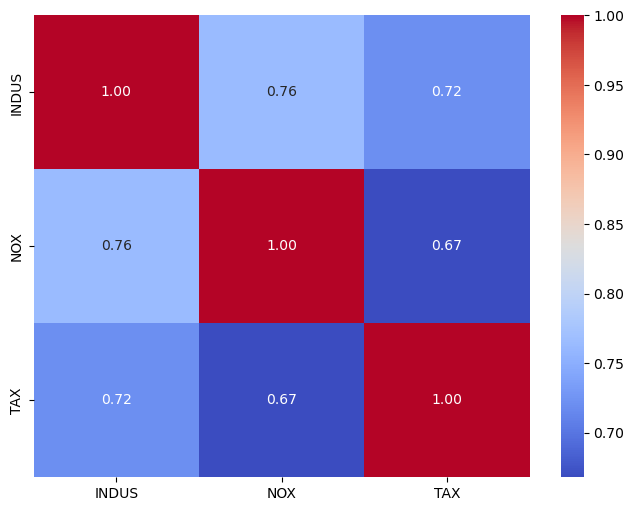

In [53]:
import seaborn as sns
corr_matrix = housing_df[['INDUS', 'NOX', 'TAX']].corr()
print(corr_matrix)
plt.figure(figsize = (8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

               CRIM        ZN     INDUS      CHAS       NOX        RM  \
CRIM       1.000000 -0.200469  0.406583 -0.055892  0.420972 -0.219247   
ZN        -0.200469  1.000000 -0.533828 -0.042697 -0.516604  0.311991   
INDUS      0.406583 -0.533828  1.000000  0.062938  0.763651 -0.391676   
CHAS      -0.055892 -0.042697  0.062938  1.000000  0.091203  0.091251   
NOX        0.420972 -0.516604  0.763651  0.091203  1.000000 -0.302188   
RM        -0.219247  0.311991 -0.391676  0.091251 -0.302188  1.000000   
AGE        0.352734 -0.569537  0.644779  0.086518  0.731470 -0.240265   
DIS       -0.379670  0.664408 -0.708027 -0.099176 -0.769230  0.205246   
RAD        0.625505 -0.311948  0.595129 -0.007368  0.611441 -0.209847   
TAX        0.582764 -0.314563  0.720760 -0.035587  0.668023 -0.292048   
PTRATIO    0.289946 -0.391679  0.383248 -0.121515  0.188933 -0.355501   
LSTAT      0.455621 -0.412995  0.603800 -0.053929  0.590879 -0.613808   
MEDV      -0.388305  0.360445 -0.483725  0.175260 -

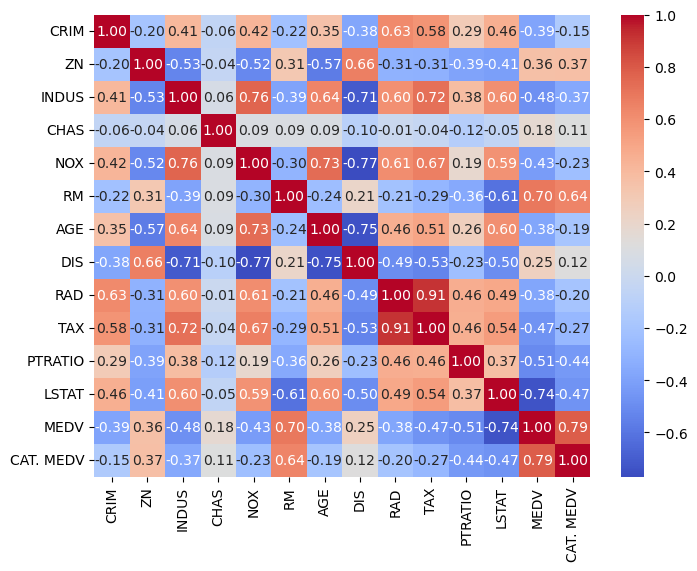

In [54]:
corr_matrix_all = housing_df[['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX',
                              'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 
                              'LSTAT', 'MEDV', 'CAT. MEDV']].corr()
print(corr_matrix_all)
plt.figure(figsize = (8,6))
sns.heatmap(corr_matrix_all, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [55]:
housing_df.columns
outcome_1 = 'MEDV'
predictors_1 = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'LSTAT']
x_1 = housing_df[predictors_1]
y_1 = housing_df[outcome_1]

In [56]:
def train_model(variables):
    model = LinearRegression()
    model.fit(x_1[variables],y_1)
    return model
def score_model(model,variables):
    return AIC_score(y_1,model.predict(x_1[variables]),model)
allVariables = x_1.columns
best_model,best_variables = backward_elimination(allVariables,train_model,
                                                 score_model,verbose=True)
print(best_variables)

Variables: CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, LSTAT
Start: score=3037.82
Step: score=3035.87, remove INDUS
Step: score=3033.94, remove AGE
Step: score=3033.94, remove None
['CRIM', 'ZN', 'CHAS', 'NOX', 'RM', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'LSTAT']


In [57]:
housing_df.columns
outcome = 'MEDV'
predictors = ['CRIM', 'CHAS','AGE','TAX', 'RM']
x = housing_df[predictors]
y = housing_df[outcome]
housing_lm = LinearRegression()
housing_lm.fit(x,y)
print('intercept ', housing_lm.intercept_)
print(pd.DataFrame({'Predictor': x.columns, 'coefficient': housing_lm.coef_}))
def train_model(variables):
    model = LinearRegression()
    model.fit(x[variables],y)
    return model
def score_model(model,variables):
    return AIC_score(y,model.predict(x[variables]),model)
allVariables = x.columns
best_model,best_variables = backward_elimination(allVariables,train_model,
                                                 score_model,verbose=True)
print(best_variables)

intercept  -18.695811985105
  Predictor  coefficient
0      CRIM    -0.122041
1      CHAS     4.369094
2       AGE    -0.040435
3       TAX    -0.009019
4        RM     7.609383
Variables: CRIM, CHAS, AGE, TAX, RM
Start: score=3238.64
Step: score=3238.64, remove None
['CRIM', 'CHAS', 'AGE', 'TAX', 'RM']
